In [1]:
import os
import json
from PIL import Image, ImageDraw
import re
import numpy as np
import cv2
import imageio
import matplotlib.pyplot as plt
import tifffile as tiff
from tqdm import tqdm
from skimage.exposure import equalize_adapthist
from scipy.stats import stats
import matplotlib.animation as animation
import pandas as pd
import csv
import shutil
from skimage.morphology import dilation, erosion



In [2]:
def make_np(img):
    return np.array(img)

def shuffle_labels(img, seed=789):
    # Find the unique labels, excluding 0 (background)
    array = make_np(img)
    unique_labels = np.unique(array[array != 0])

    # Generate new labels (random and unique) for each cell type
    # Ensure new labels do not conflict with existing labels
    # max_label = array.max()
    max_label = 0
    new_labels = np.arange(max_label + 1, max_label + 1 + len(unique_labels))

    # Randomly shuffle the new labels
    np.random.seed(seed)
    np.random.shuffle(new_labels)

    # Create a mapping from old labels to new labels
    label_mapping = {old: new for old, new in zip(unique_labels, new_labels)}

    # Apply the mapping to the array
    shuffled_array = np.copy(array)
    for old_label, new_label in label_mapping.items():
        shuffled_array[array == old_label] = new_label
    return shuffled_array

def plot_labels(shuffled, original, ax, title=None,
                txt_args={'color':'red', 'ha':'center', 'va':'center', 
                          'fontsize':'x-large', 'fontweight':'bold'},
                cmap='gist_earth'):
    ax.imshow(shuffled, cmap=cmap)
    ax.set_title(title)
    for label in np.unique(original):
        if label != 0:
            inds = np.argwhere(original == label)
            loc = inds.mean(0)
            ax.text(loc[1], loc[0], str(label), **txt_args)


def read_changes(file_path, row):
    with open(file_path, 'r') as handle:
        reader = csv.reader(handle, delimiter=' ')
        for i in range(row):
            next(reader)
        curr_row = next(reader)
        tuples = [tuple(map(int, item.split(','))) for item in curr_row]
    return tuples

def relabel_image(original, file_path, row):
    tuples = read_changes(file_path, row)
    new_img = original.copy()
    for t in tuples:
        new_img[original == t[0]] = t[1]
    return new_img



def plot_raw(shuffled, original, ax, title=None,
                txt_args={'color':'red', 'ha':'center', 'va':'center', 
                          'fontsize':'x-large', 'fontweight':'bold'},
                cmap_raw='gray', cmap_seg='gist_earth', alpha=.5):
    ax.imshow(shuffled, cmap=cmap_raw)
    ax.set_title(title)
    
    for label in np.unique(original):
        if label != 0:
            inds = np.argwhere(original == label)
            loc = inds.mean(0)
            ax.text(loc[1], loc[0], str(label), **txt_args)

    tmp_seg = shuffle_labels(make_np(original))
    tmp_seg = np.ma.masked_where(tmp_seg == 0, tmp_seg)
    ax.imshow(tmp_seg, alpha=alpha, cmap=cmap_seg)



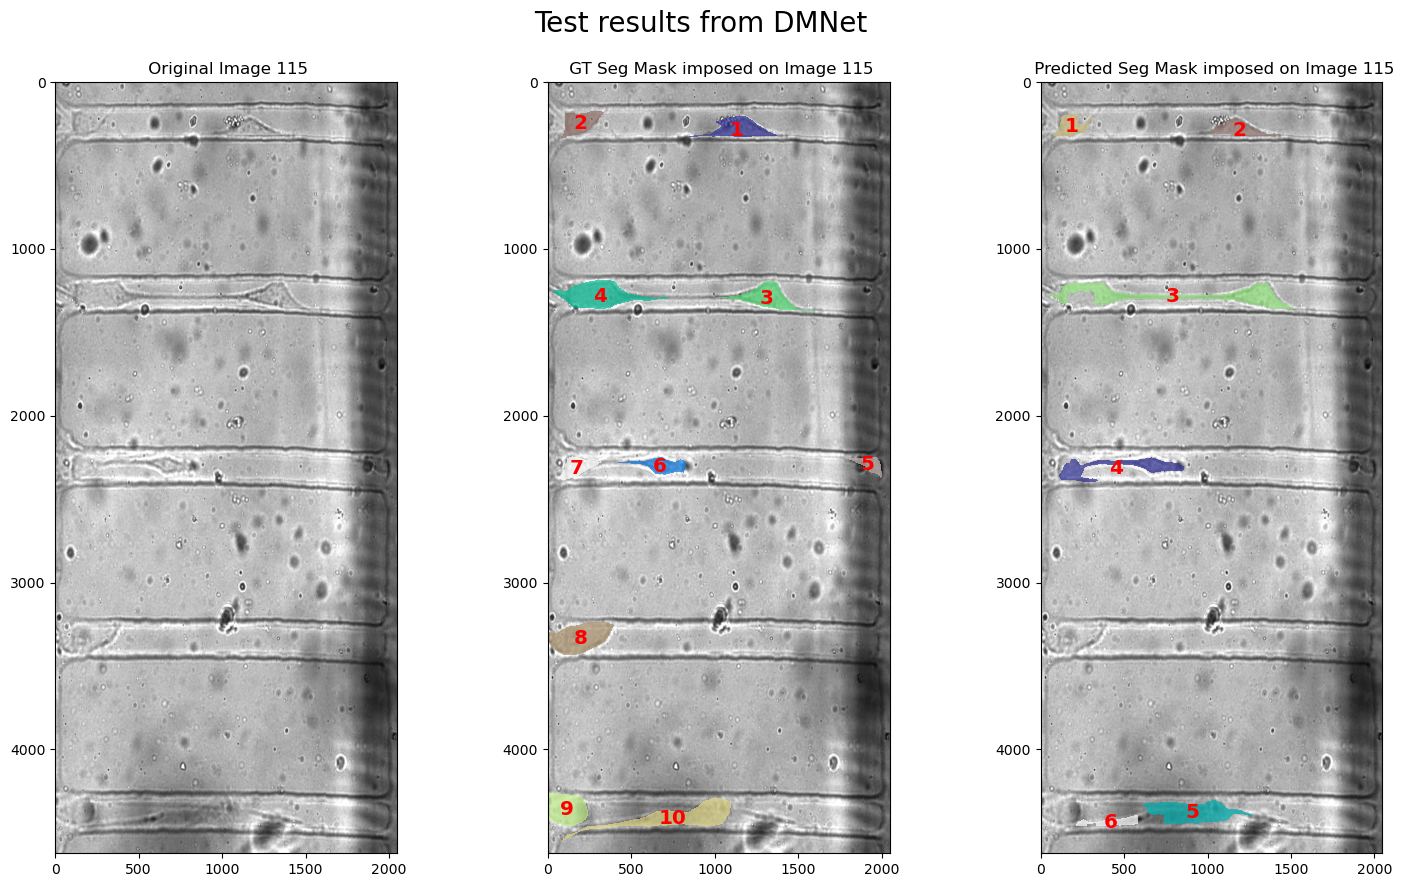

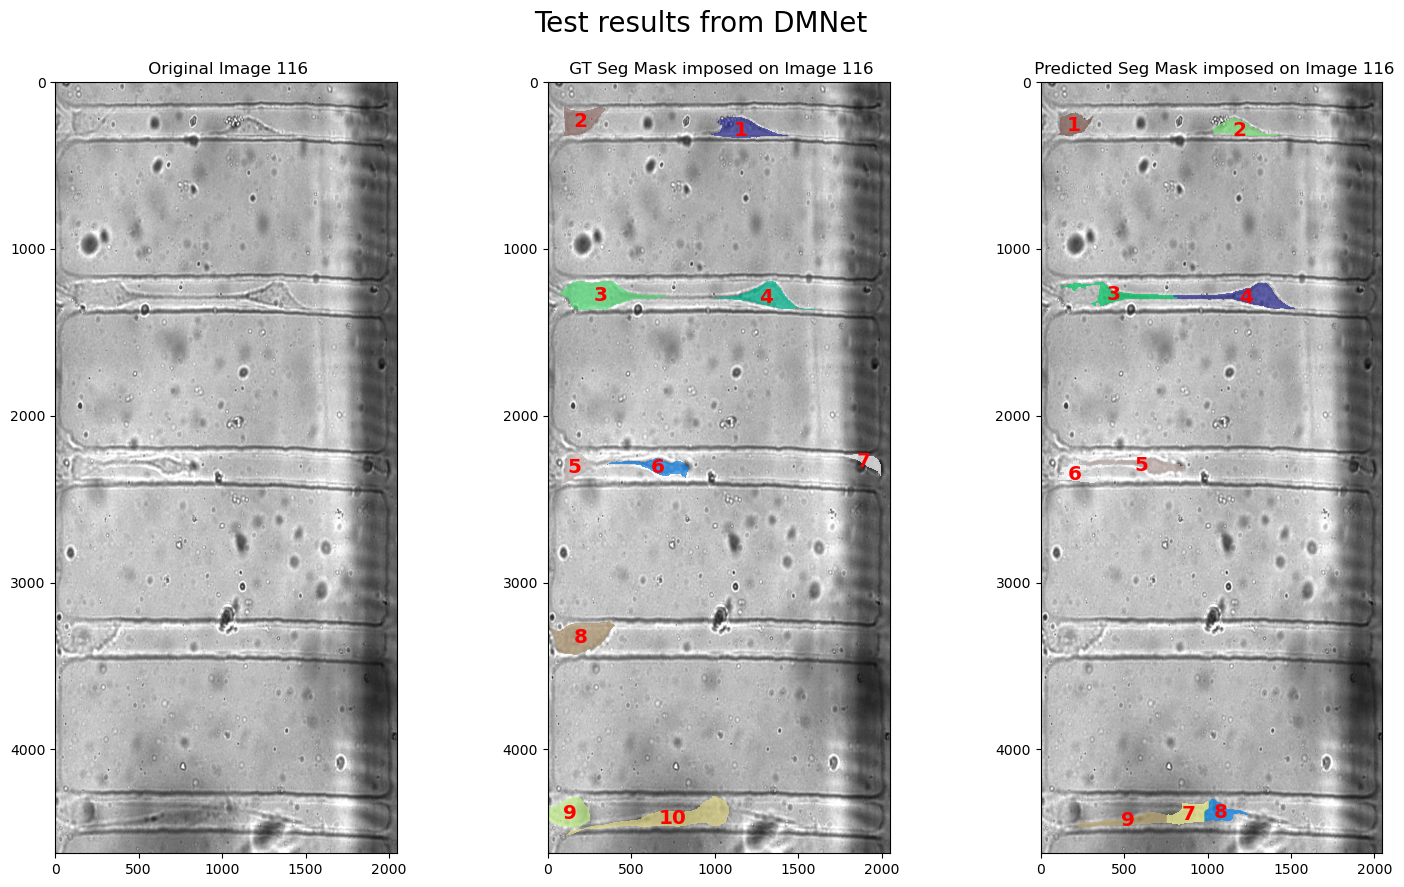

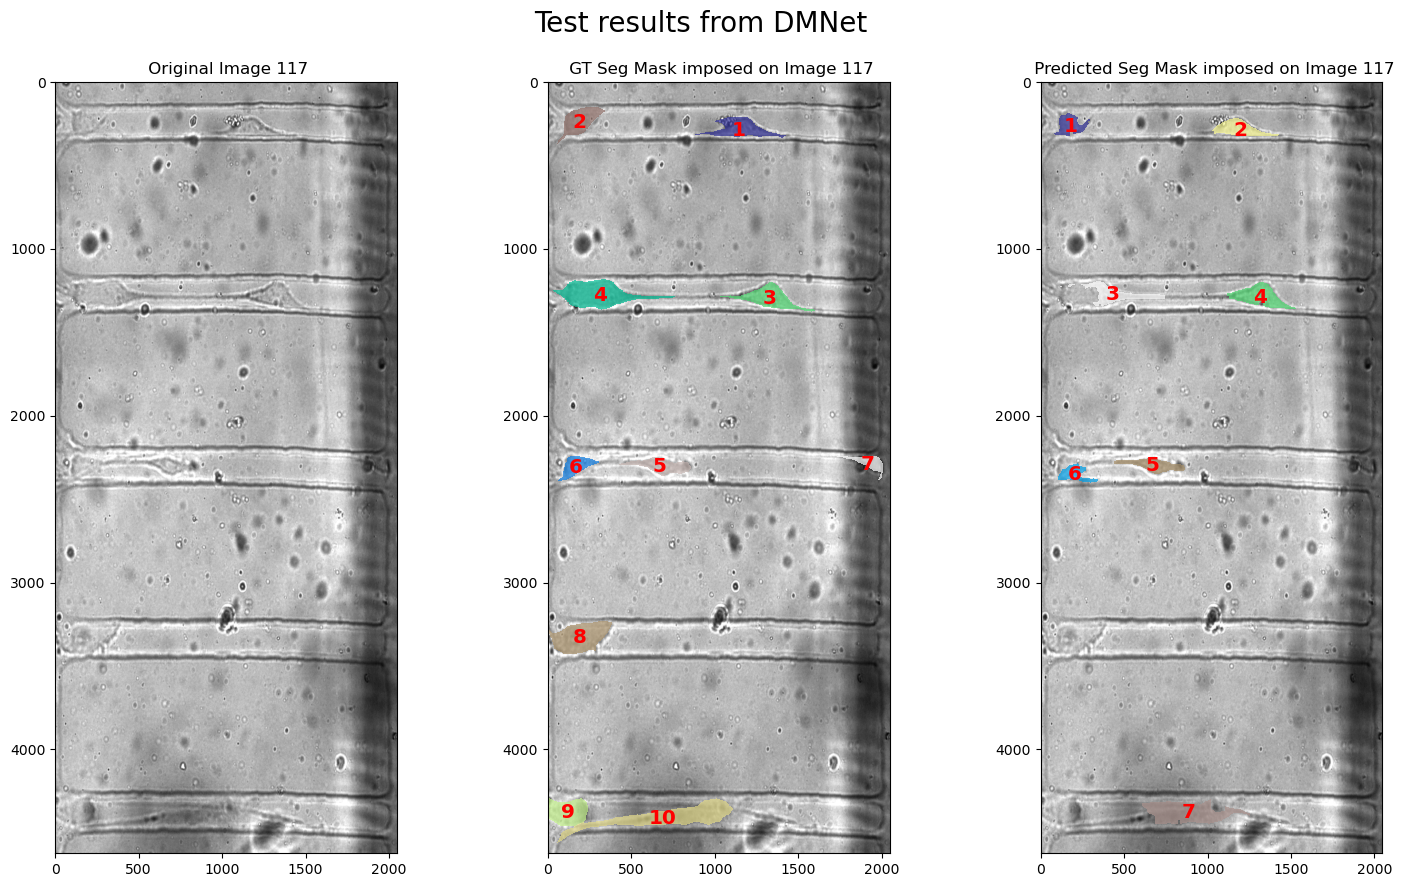

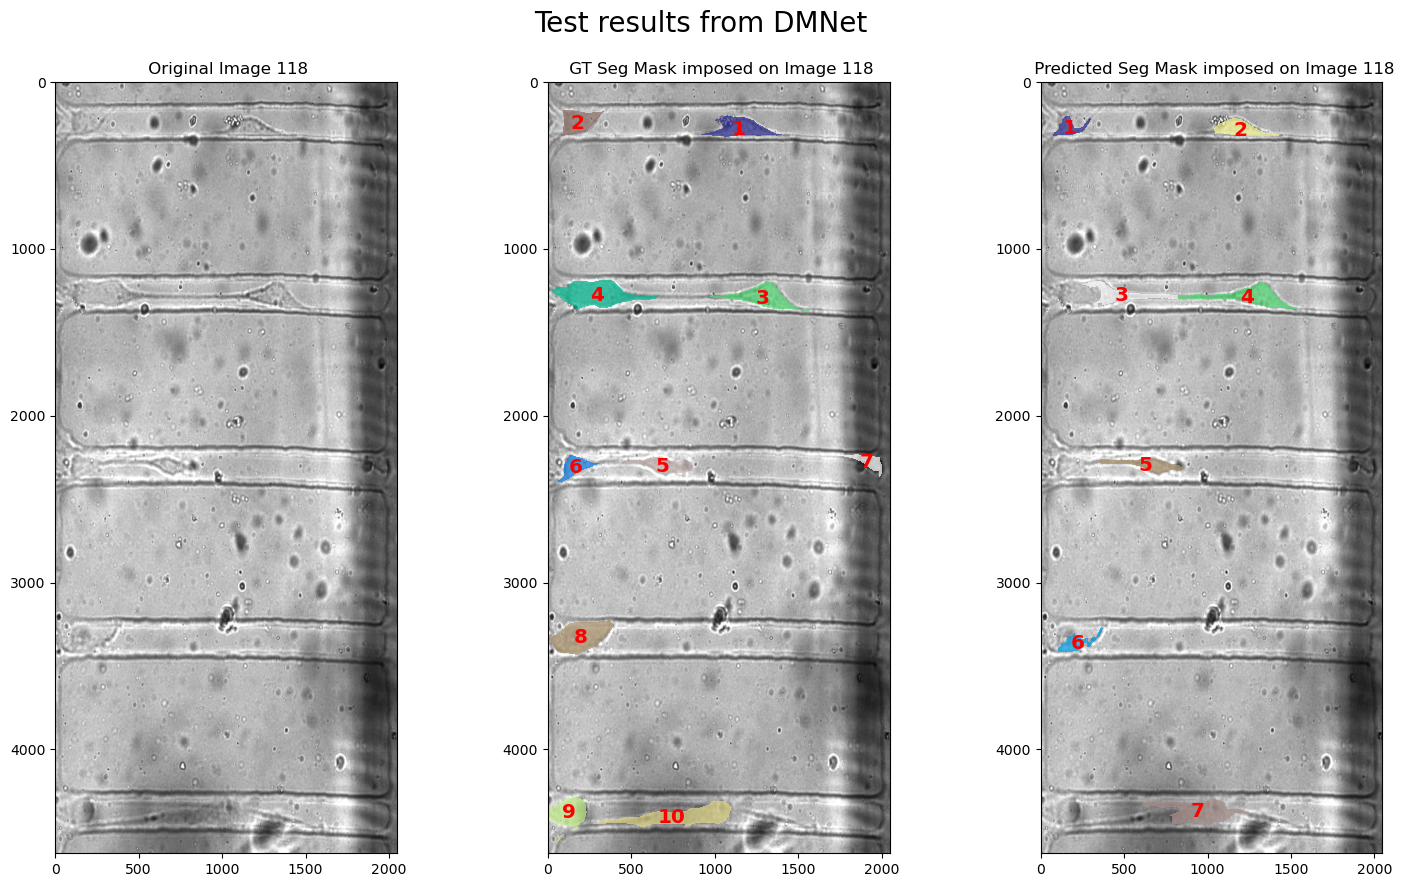

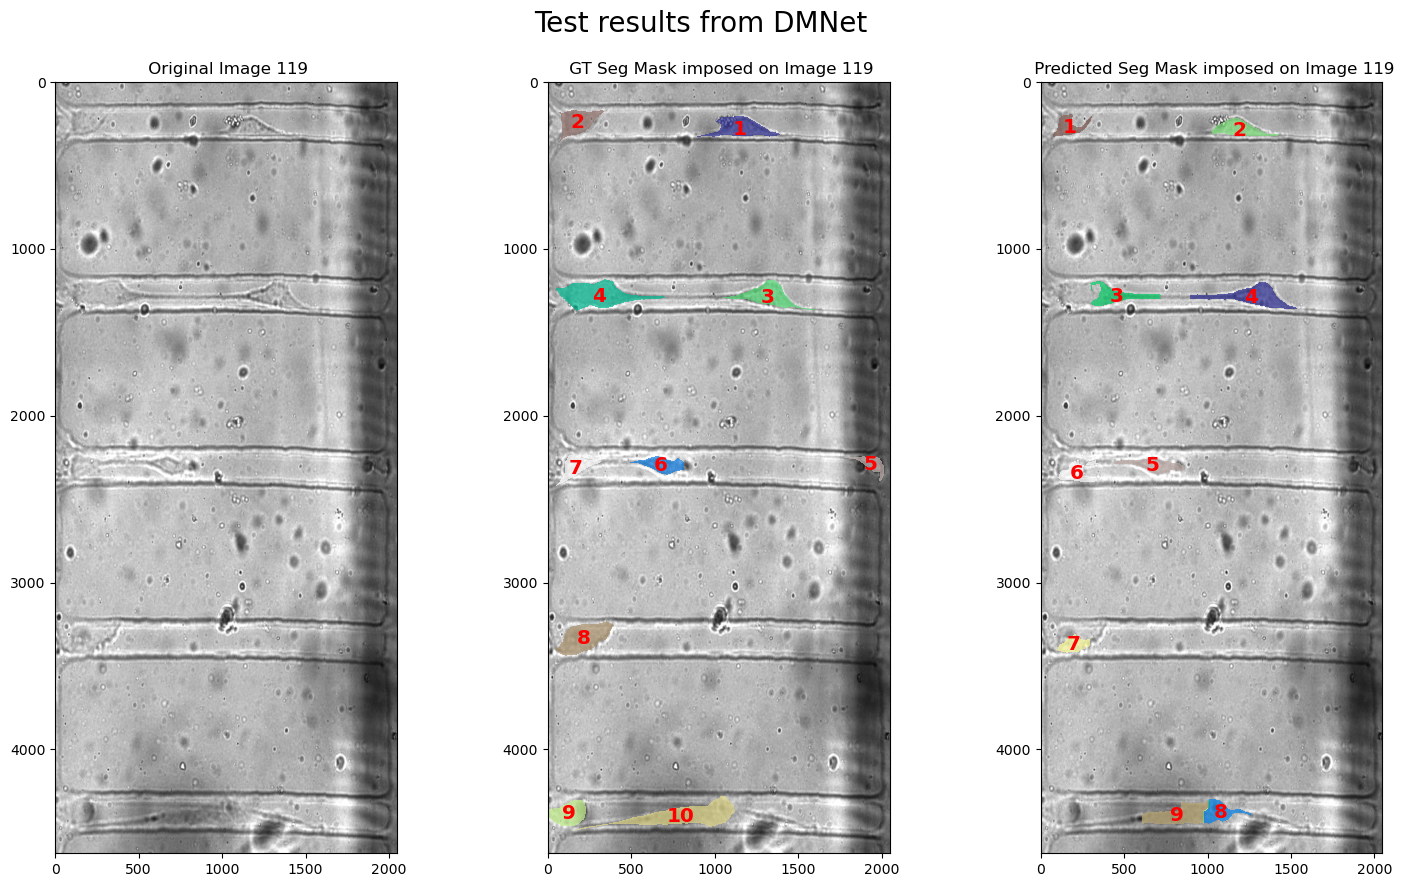

In [7]:

def make_np(img):
    return np.array(img)

def shuffle_labels(img, seed=784):
    # Find the unique labels, excluding 0 (background)
    # array = make_np(img)
    array = img
    unique_labels = np.unique(array[array != 0])

    # Generate new labels (random and unique) for each cell type
    # Ensure new labels do not conflict with existing labels
    # max_label = array.max()
    max_label = 0
    new_labels = np.arange(max_label + 1, max_label + 1 + len(unique_labels))

    # Randomly shuffle the new labels
    np.random.seed(seed)
    np.random.shuffle(new_labels)

    # Create a mapping from old labels to new labels
    label_mapping = {old: new for old, new in zip(unique_labels, new_labels)}

    # Apply the mapping to the array
    shuffled_array = np.copy(array)
    for old_label, new_label in label_mapping.items():
        shuffled_array[array == old_label] = new_label
    return shuffled_array

def plot_labels(shuffled, original, ax, title=None,
                txt_args={'color':'red', 'ha':'center', 'va':'center', 
                          'fontsize':'x-large', 'fontweight':'bold'}):
    ax.imshow(shuffled, cmap='gist_earth')
    ax.set_title(title)
    for label in np.unique(original):
        if label != 0:
            inds = np.argwhere(original == label)
            loc = inds.mean(0)
            ax.text(loc[1], loc[0], str(label), **txt_args)



def plot_raw(shuffled, original, ax, title=None,
                txt_args={'color':'red', 'ha':'center', 'va':'center', 
                          'fontsize':'x-large', 'fontweight':'bold'},
                cmap_raw='gray', cmap_seg='gist_earth', alpha=.5):
    ax.imshow(shuffled, cmap=cmap_raw)
    ax.set_title(title)
    
    for label in np.unique(original):
        if label != 0:
            inds = np.argwhere(original == label)
            loc = inds.mean(0)
            ax.text(loc[1], loc[0], str(label), **txt_args)

    tmp_seg = shuffle_labels(make_np(original))
    tmp_seg = np.ma.masked_where(tmp_seg == 0, tmp_seg)
    ax.imshow(tmp_seg, alpha=alpha, cmap=cmap_seg)



for i in range(115,120):
    # Path to the raw image (like datasets/raw/Cell_Data/02/imagename.tif)
    # og_img = tiff.imread(f"/home/MinaHossain/DMNet_Rina/training_codes/Data/train/Cell-Data-{data_type}-V1/02/t{i:04d}.tif")
    # og_img = tiff.imread(f"/data/MinaHossain/Cell_Data_All/Cell_Data_Processed/July_Train_lastweek/6row_images_min_Original-V2/02/t{i:04d}.tif")   
    # image_path = f"/data/MinaHossain/Cell_Data_All/Cell_Data_Processed/July_Train_lastweek/6row_images_min_Original-V2/02/t{i:04d}.tif"

    og_img = tiff.imread(f"/data/MinaHossain/Cell_Data_All/Cell_Data_Processed/Train_June2025/6row_images_L2L-TE_Raw/02/t{i:04d}.tif")
    image_path = f"/data/MinaHossain/Cell_Data_All/Cell_Data_Processed/Train_June2025/6row_images_L2L-TE_Raw/02/t{i:04d}.tif"

    seg_img = Image.open(image_path).convert('L')
    seg_lab = Image.open(f"/data/MinaHossain/Cell_Data_All/Cell_Data_Processed/Train_June2025/6row_images_L2L-TE_Raw/02_GT/SEG/man_seg{i:04d}.tif").convert('L')
   
    # image_path2 = f"/home/MinaHossain/Label_5004/6row_images_min_Original/02/t{i:04d}.tif"
    # seg_img2 = Image.open(image_path2).convert('L')
    # seg_lab2 = Image.open(f"/data/MinaHossain/Cell_Data_All/Cell_Data_Processed/July_Train_lastweek/6row_images_Track/HP1_TRA/mask{i:04d}.tif").convert('L')
    seg_lab2 = Image.open(f"/home/MinaHossain/DMNet_Rina/Cell-Data-P2/25A_RES-GT/mask{i:04d}.tif").convert('L')
    
    
       
      
    fig, ax = plt.subplots(1, 3)
    fig.set_size_inches(15, 9)
    fig.suptitle('Test results from DMNet ',fontsize=20)
    
    ax[0].imshow(og_img, cmap='gist_gray', alpha=0.99)
    ax[0].set_title(f" Original Image {i}")
    plot_raw(seg_img, make_np(seg_lab), ax[1], f" GT Seg Mask imposed on Image {i}",alpha=.7, cmap_seg='terrain')
    plot_raw(seg_img, make_np(seg_lab2), ax[2], f" Predicted Seg Mask imposed on Image {i}",alpha=.7, cmap_seg='terrain')
    
    

    fig.tight_layout()
    fig.subplots_adjust(top=0.9)
    # plt.savefig(f"/home/MinaHossain/DMNet_Rina/Plot_DM-Net/{Data_file}/{i:04d}.png")
    plt.show()
    
